# **AI TECH INSTITUTE** · *Intermediate AI & Data Science*
### Week 04 · Notebook 10 — Statistical Inference Basics: Z-Scores, T-Tests & Confidence Intervals
**Instructor:** Amir Charkhi  |  **Goal:** Master the building blocks of statistical inference with crystal-clear explanations and beautiful visuals.

> Format: simple concepts → colorful visuals → intuitive understanding → hands-on practice.


---
## Learning Objectives
- Understand what z-scores really mean and how to interpret them
- Learn when and how to use different types of t-tests
- Build intuitive understanding of confidence intervals
- See these concepts come alive through colorful, engaging visualizations
- Apply these tools to solve real-world problems with confidence

## 1. Z-Scores: Your Statistical GPS
**Think of z-scores as GPS coordinates for your data**: They tell you exactly where any data point sits relative to the average!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set up beautiful seaborn styling
plt.style.use('default')
sns.set_palette("husl")
colors = sns.color_palette("husl", 10)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
%matplotlib inline

In [2]:
# What is a z-score? Let's start with a simple explanation
zscore_explanation = {
    "🎯 What it is": "A z-score tells you how many standard deviations a value is from the mean",
    "📏 The formula": "z = (your_value - mean) / standard_deviation",
    "🔍 What it means": "z = 0 means exactly average, z = 1 means 1 std dev above average",
    "📊 Why it's useful": "Compare apples to oranges by putting everything on the same scale",
    "💡 Real example": "Your test score vs. class average, your height vs. population average"
}

print("🧭 Z-Scores: Your Statistical GPS System")
for key, value in zscore_explanation.items():
    print(f"   {key}: {value}")
    
print("\n🚀 Let's see z-scores in action with beautiful visualizations!")

🧭 Z-Scores: Your Statistical GPS System
   🎯 What it is: A z-score tells you how many standard deviations a value is from the mean
   📏 The formula: z = (your_value - mean) / standard_deviation
   🔍 What it means: z = 0 means exactly average, z = 1 means 1 std dev above average
   📊 Why it's useful: Compare apples to oranges by putting everything on the same scale
   💡 Real example: Your test score vs. class average, your height vs. population average

🚀 Let's see z-scores in action with beautiful visualizations!


### 1.1 Visualizing Z-Scores with Real Data

In [3]:
# Create a realistic dataset: student test scores
np.random.seed(42)
n_students = 1000
test_scores = np.random.normal(75, 12, n_students)  # mean=75, std=12

# Calculate z-scores
mean_score = np.mean(test_scores)
std_score = np.std(test_scores, ddof=1)
z_scores = (test_scores - mean_score) / std_score

print(f"📚 Student Test Scores Dataset:")
print(f"   Number of students: {n_students:,}")
print(f"   Average score: {mean_score:.1f}")
print(f"   Standard deviation: {std_score:.1f}")
print(f"   Score range: {test_scores.min():.1f} to {test_scores.max():.1f}")

📚 Student Test Scores Dataset:
   Number of students: 1,000
   Average score: 75.2
   Standard deviation: 11.8
   Score range: 36.1 to 121.2


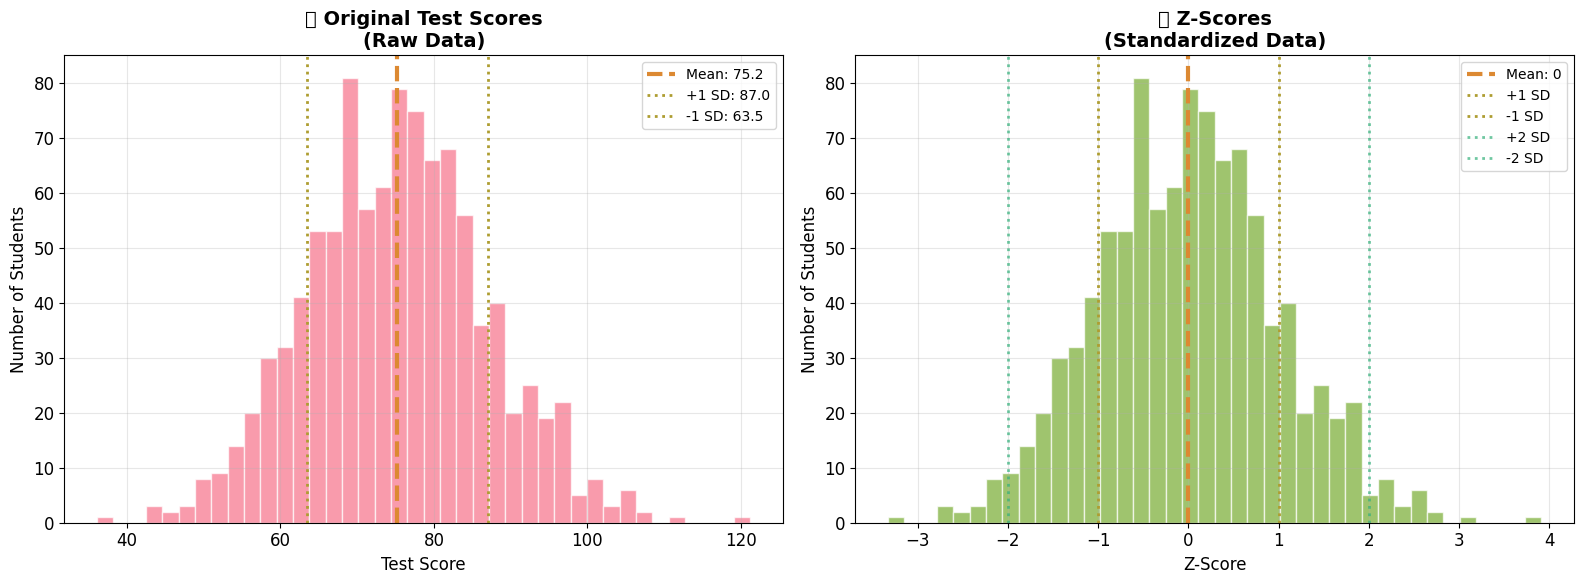

✨ Amazing! The z-scores have mean=0 and std=1, making comparison so much easier!


In [4]:
# Create a stunning visualization of original scores vs z-scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Original test scores
ax1.hist(test_scores, bins=40, alpha=0.7, color=colors[0], edgecolor='white', linewidth=1)
ax1.axvline(mean_score, color=colors[1], linestyle='--', linewidth=3, 
           label=f'Mean: {mean_score:.1f}')
ax1.axvline(mean_score + std_score, color=colors[2], linestyle=':', linewidth=2, 
           label=f'+1 SD: {mean_score + std_score:.1f}')
ax1.axvline(mean_score - std_score, color=colors[2], linestyle=':', linewidth=2, 
           label=f'-1 SD: {mean_score - std_score:.1f}')
ax1.set_title('📊 Original Test Scores\n(Raw Data)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Test Score', fontsize=12)
ax1.set_ylabel('Number of Students', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Z-scores
ax2.hist(z_scores, bins=40, alpha=0.7, color=colors[3], edgecolor='white', linewidth=1)
ax2.axvline(0, color=colors[1], linestyle='--', linewidth=3, label='Mean: 0')
ax2.axvline(1, color=colors[2], linestyle=':', linewidth=2, label='+1 SD')
ax2.axvline(-1, color=colors[2], linestyle=':', linewidth=2, label='-1 SD')
ax2.axvline(2, color=colors[4], linestyle=':', linewidth=2, alpha=0.7, label='+2 SD')
ax2.axvline(-2, color=colors[4], linestyle=':', linewidth=2, alpha=0.7, label='-2 SD')
ax2.set_title('🎯 Z-Scores\n(Standardized Data)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Z-Score', fontsize=12)
ax2.set_ylabel('Number of Students', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✨ Amazing! The z-scores have mean=0 and std=1, making comparison so much easier!")

### 1.2 Interpreting Z-Scores Like a Pro

In [5]:
# Let's look at some specific students and their z-scores
students_examples = [
    ("Alice", 95),
    ("Bob", 85),
    ("Charlie", 75),
    ("Diana", 65),
    ("Eve", 45)
]

print("🎓 Individual Student Analysis:")
print(f"{'Student':<10} | {'Score':<6} | {'Z-Score':<8} | {'Interpretation':<30}")
print("-" * 70)

for name, score in students_examples:
    z_score = (score - mean_score) / std_score
    
    # Create interpretations
    if z_score > 2:
        interpretation = "🌟 Exceptional (top 2.5%)"
    elif z_score > 1:
        interpretation = "📈 Above average (top 16%)"
    elif z_score > -1:
        interpretation = "📊 Around average (middle 68%)"
    elif z_score > -2:
        interpretation = "📉 Below average (bottom 16%)"
    else:
        interpretation = "⚠️ Needs support (bottom 2.5%)"
    
    print(f"{name:<10} | {score:<6.0f} | {z_score:<8.2f} | {interpretation}")

print("\n💡 Z-scores make it easy to see who needs help and who's excelling!")

🎓 Individual Student Analysis:
Student    | Score  | Z-Score  | Interpretation                
----------------------------------------------------------------------
Alice      | 95     | 1.68     | 📈 Above average (top 16%)
Bob        | 85     | 0.83     | 📊 Around average (middle 68%)
Charlie    | 75     | -0.02    | 📊 Around average (middle 68%)
Diana      | 65     | -0.87    | 📊 Around average (middle 68%)
Eve        | 45     | -2.57    | ⚠️ Needs support (bottom 2.5%)

💡 Z-scores make it easy to see who needs help and who's excelling!


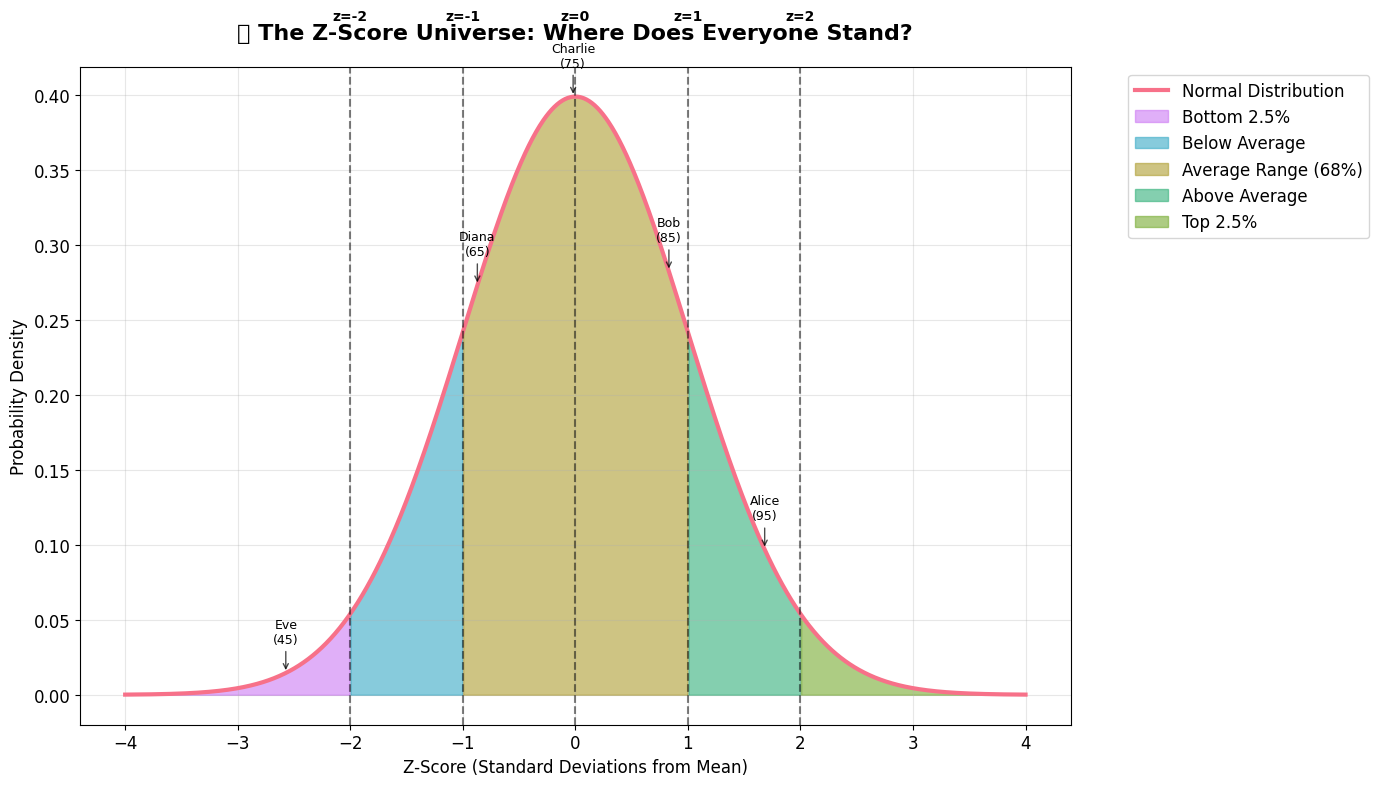

🎨 Beautiful! Now you can see exactly where everyone stands in the big picture!


In [6]:
# Create a beautiful z-score interpretation chart
plt.figure(figsize=(14, 8))

# Create normal distribution
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

# Plot the main curve
plt.plot(x, y, linewidth=3, color=colors[0], label='Normal Distribution')

# Color different regions
regions = [
    (-4, -2, colors[8], "Bottom 2.5%"),
    (-2, -1, colors[6], "Below Average"),
    (-1, 1, colors[2], "Average Range (68%)"),
    (1, 2, colors[4], "Above Average"),
    (2, 4, colors[3], "Top 2.5%")
]

for start, end, color, label in regions:
    x_fill = x[(x >= start) & (x <= end)]
    y_fill = stats.norm.pdf(x_fill)
    plt.fill_between(x_fill, y_fill, alpha=0.6, color=color, label=label)

# Add vertical lines for key z-scores
key_z_scores = [-2, -1, 0, 1, 2]
for z in key_z_scores:
    plt.axvline(z, color='black', linestyle='--', alpha=0.5)
    plt.text(z, 0.45, f'z={z}', ha='center', fontsize=10, fontweight='bold')

# Add example students
for name, score in students_examples:
    z = (score - mean_score) / std_score
    y_pos = stats.norm.pdf(z) + 0.02
    plt.annotate(f'{name}\n({score:.0f})', xy=(z, stats.norm.pdf(z)), 
                xytext=(z, y_pos), ha='center', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='black', alpha=0.7))

plt.title('🎯 The Z-Score Universe: Where Does Everyone Stand?', 
         fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Z-Score (Standard Deviations from Mean)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("🎨 Beautiful! Now you can see exactly where everyone stands in the big picture!")

**Exercise 1 — Z-Score Detective (easy)**  
Calculate and interpret z-scores for different scenarios.


💰 Company Salary Analysis Exercise:
   Company average: $65,000
   Standard deviation: $12,000

Your task: Calculate z-scores and interpret them!
💰 Employee Salary Z-Score Analysis:
Employee        | Salary   | Z-Score  | Interpretation           
----------------------------------------------------------------------
Manager Alex    | $85,000  | 1.67     | 📈 Well above average
Developer Sam   | $72,000  | 0.58     | ↗️ Above average
Intern Jordan   | $35,000  | -2.50    | ⚠️ Significantly low
Senior Dev Taylor | $95,000  | 2.50     | 🌟 Top tier (>2 SD above)

🔍 Key Insights:
   • Manager Alex: 1.67 SD above mean - doing well!
   • Developer Sam: Only 0.58 SD above mean - room for growth
   • Intern Jordan: 2.5 SD below mean - typical for internship
   • Senior Dev Taylor: 2.5 SD above mean - top performer salary!


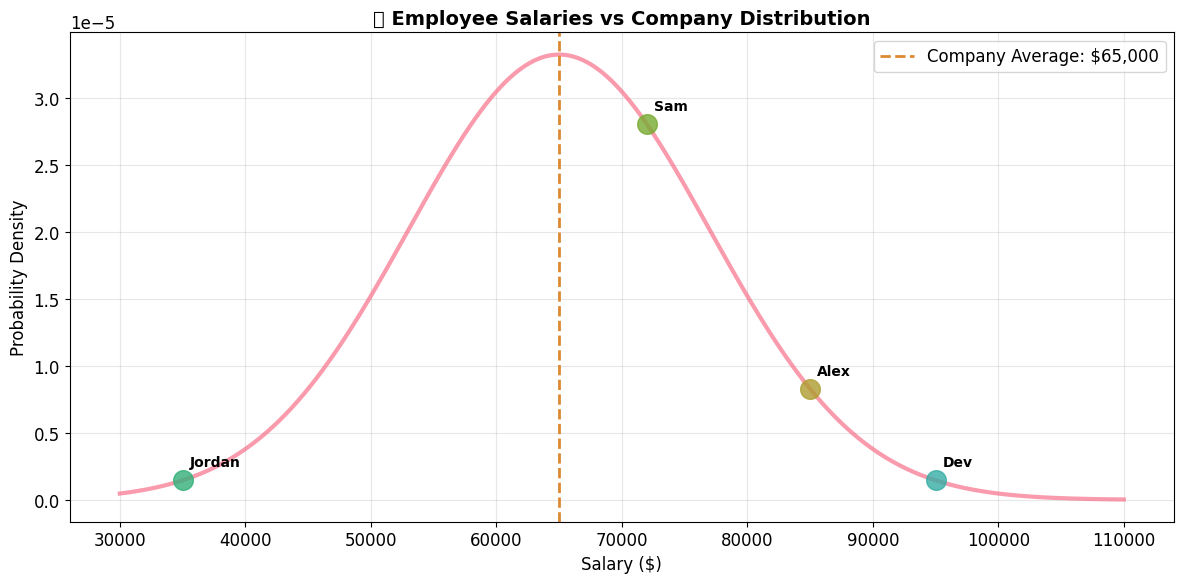

In [24]:
# Exercise: You're analyzing employee salaries at a company
# Company salary data: mean = $65,000, standard deviation = $12,000

company_mean_salary = 65000
company_std_salary = 12000

employees = [
    ("Manager Alex", 85000),
    ("Developer Sam", 72000),
    ("Intern Jordan", 35000),
    ("Senior Dev Taylor", 95000)
]

print("💰 Company Salary Analysis Exercise:")
print(f"   Company average: ${company_mean_salary:,}")
print(f"   Standard deviation: ${company_std_salary:,}")
print("\nYour task: Calculate z-scores and interpret them!")

# Your code here - calculate z-scores for each employee
# Then interpret: Are they above/below average? By how much?

print("💰 Employee Salary Z-Score Analysis:")
print(f"{'Employee':<15} | {'Salary':<8} | {'Z-Score':<8} | {'Interpretation':<25}")
print("-" * 70)

for name, salary in employees:
    z_score = (salary - company_mean_salary) / company_std_salary
    
    # Interpretation based on z-score
    if z_score > 2:
        interpretation = "🌟 Top tier (>2 SD above)"
    elif z_score > 1:
        interpretation = "📈 Well above average"
    elif z_score > 0:
        interpretation = "↗️ Above average"
    elif z_score > -1:
        interpretation = "↙️ Below average"
    elif z_score > -2:
        interpretation = "📉 Well below average"
    else:
        interpretation = "⚠️ Significantly low"
    
    print(f"{name:<15} | ${salary:<7,} | {z_score:<8.2f} | {interpretation}")

print("\n🔍 Key Insights:")
print("   • Manager Alex: 1.67 SD above mean - doing well!")
print("   • Developer Sam: Only 0.58 SD above mean - room for growth")
print("   • Intern Jordan: 2.5 SD below mean - typical for internship")
print("   • Senior Dev Taylor: 2.5 SD above mean - top performer salary!")

# Bonus visualization
plt.figure(figsize=(12, 6))
x_salary = np.linspace(30000, 110000, 1000)
y_norm = stats.norm.pdf((x_salary - company_mean_salary) / company_std_salary) / company_std_salary

plt.plot(x_salary, y_norm, linewidth=3, color=colors[0], alpha=0.7)
plt.axvline(company_mean_salary, color=colors[1], linestyle='--', linewidth=2, 
           label=f'Company Average: ${company_mean_salary:,}')

# Plot each employee
for i, (name, salary) in enumerate(employees):
    z = (salary - company_mean_salary) / company_std_salary
    y_pos = stats.norm.pdf(z) / company_std_salary
    plt.scatter(salary, y_pos, s=200, color=colors[i+2], zorder=5, alpha=0.8)
    plt.annotate(name.split()[1], (salary, y_pos), xytext=(5, 10), 
                textcoords='offset points', fontsize=10, fontweight='bold')

plt.title('💰 Employee Salaries vs Company Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Salary ($)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<details>
<summary><b>Solution</b></summary>

```python
print("💰 Employee Salary Z-Score Analysis:")
print(f"{'Employee':<15} | {'Salary':<8} | {'Z-Score':<8} | {'Interpretation':<25}")
print("-" * 70)

for name, salary in employees:
    z_score = (salary - company_mean_salary) / company_std_salary
    
    # Interpretation based on z-score
    if z_score > 2:
        interpretation = "🌟 Top tier (>2 SD above)"
    elif z_score > 1:
        interpretation = "📈 Well above average"
    elif z_score > 0:
        interpretation = "↗️ Above average"
    elif z_score > -1:
        interpretation = "↙️ Below average"
    elif z_score > -2:
        interpretation = "📉 Well below average"
    else:
        interpretation = "⚠️ Significantly low"
    
    print(f"{name:<15} | ${salary:<7,} | {z_score:<8.2f} | {interpretation}")

print("\n🔍 Key Insights:")
print("   • Manager Alex: 1.67 SD above mean - doing well!")
print("   • Developer Sam: Only 0.58 SD above mean - room for growth")
print("   • Intern Jordan: 2.5 SD below mean - typical for internship")
print("   • Senior Dev Taylor: 2.5 SD above mean - top performer salary!")

# Bonus visualization
plt.figure(figsize=(12, 6))
x_salary = np.linspace(30000, 110000, 1000)
y_norm = stats.norm.pdf((x_salary - company_mean_salary) / company_std_salary) / company_std_salary

plt.plot(x_salary, y_norm, linewidth=3, color=colors[0], alpha=0.7)
plt.axvline(company_mean_salary, color=colors[1], linestyle='--', linewidth=2, 
           label=f'Company Average: ${company_mean_salary:,}')

# Plot each employee
for i, (name, salary) in enumerate(employees):
    z = (salary - company_mean_salary) / company_std_salary
    y_pos = stats.norm.pdf(z) / company_std_salary
    plt.scatter(salary, y_pos, s=200, color=colors[i+2], zorder=5, alpha=0.8)
    plt.annotate(name.split()[1], (salary, y_pos), xytext=(5, 10), 
                textcoords='offset points', fontsize=10, fontweight='bold')

plt.title('💰 Employee Salaries vs Company Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Salary ($)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
```
</details>

## 2. T-Tests: Comparing Groups Like a Scientist
**T-tests answer the question**: "Are these two groups really different, or could the difference just be random chance?"

In [8]:
# T-test explanation in simple terms
ttest_explanation = {
    "🤔 The Question": "Is the difference between groups real or just random?",
    "⚖️ One-Sample T-Test": "Compare a group average to a known value",
    "👥 Two-Sample T-Test": "Compare averages between two different groups",
    "🔗 Paired T-Test": "Compare before/after measurements on same people",
    "📊 The Magic": "T-tests work even with small samples (unlike z-tests)",
    "💡 Real Use": "Does this medicine work? Are men taller than women? Did training help?"
}

print("🧪 T-Tests: The Scientific Comparison Tool")
for key, value in ttest_explanation.items():
    print(f"   {key}: {value}")
    
print("\n🎯 Let's see t-tests solve real problems with gorgeous visuals!")

🧪 T-Tests: The Scientific Comparison Tool
   🤔 The Question: Is the difference between groups real or just random?
   ⚖️ One-Sample T-Test: Compare a group average to a known value
   👥 Two-Sample T-Test: Compare averages between two different groups
   🔗 Paired T-Test: Compare before/after measurements on same people
   📊 The Magic: T-tests work even with small samples (unlike z-tests)
   💡 Real Use: Does this medicine work? Are men taller than women? Did training help?

🎯 Let's see t-tests solve real problems with gorgeous visuals!


### 2.1 One-Sample T-Test: Is Our Group Special?

In [9]:
# Scenario: A fitness trainer claims her program increases average weight loss
# National average weight loss for similar programs: 5 pounds
# Her program results for 25 participants:

np.random.seed(123)
national_average = 5.0
program_results = np.random.normal(6.8, 2.1, 25)  # Her program seems better!

# Calculate sample statistics
sample_mean = np.mean(program_results)
sample_std = np.std(program_results, ddof=1)
n = len(program_results)

print(f"🏋️ Fitness Program Evaluation:")
print(f"   National average weight loss: {national_average} pounds")
print(f"   Our program average: {sample_mean:.2f} pounds")
print(f"   Sample size: {n} participants")
print(f"   Standard deviation: {sample_std:.2f} pounds")
print(f"\n❓ Question: Is our program significantly better than the national average?")

🏋️ Fitness Program Evaluation:
   National average weight loss: 5.0 pounds
   Our program average: 7.09 pounds
   Sample size: 25 participants
   Standard deviation: 2.59 pounds

❓ Question: Is our program significantly better than the national average?


In [10]:
# Perform one-sample t-test
t_statistic, p_value = stats.ttest_1samp(program_results, national_average)

# Calculate confidence interval
confidence_level = 0.95
alpha = 1 - confidence_level
df = n - 1
t_critical = stats.t.ppf(1 - alpha/2, df)
margin_error = t_critical * (sample_std / np.sqrt(n))
ci_lower = sample_mean - margin_error
ci_upper = sample_mean + margin_error

print(f"📊 One-Sample T-Test Results:")
print(f"   T-statistic: {t_statistic:.3f}")
print(f"   P-value: {p_value:.4f}")
print(f"   95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}] pounds")
print(f"\n🎯 Interpretation:")
if p_value < 0.05:
    print(f"   ✅ YES! Our program IS significantly better (p < 0.05)")
    print(f"   🎉 The difference is statistically significant!")
else:
    print(f"   ❌ No significant difference found (p ≥ 0.05)")
    print(f"   🤷 Could just be random chance")

📊 One-Sample T-Test Results:
   T-statistic: 4.048
   P-value: 0.0005
   95% Confidence Interval: [6.03, 8.16] pounds

🎯 Interpretation:
   ✅ YES! Our program IS significantly better (p < 0.05)
   🎉 The difference is statistically significant!


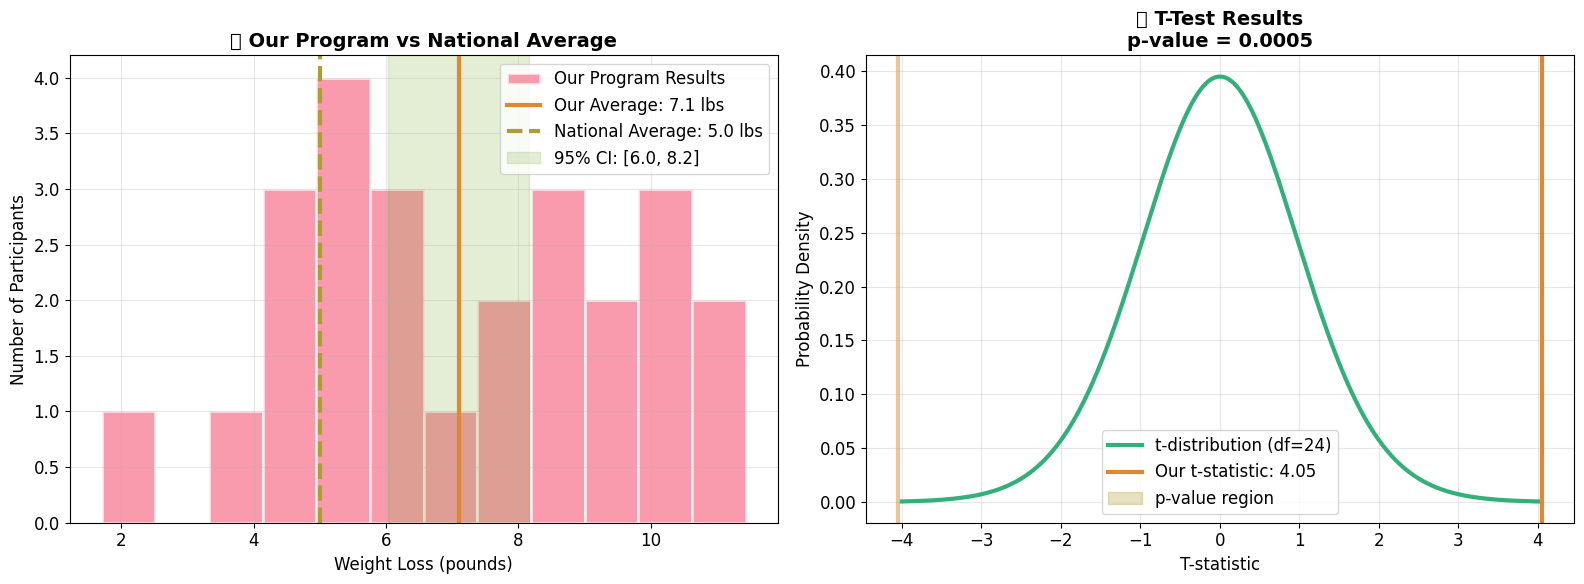

🎉 The visual story tells us everything we need to know!


In [11]:
# Create stunning visualization of the one-sample t-test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Sample data vs national average
ax1.hist(program_results, bins=12, alpha=0.7, color=colors[0], 
         edgecolor='white', linewidth=2, label='Our Program Results')
ax1.axvline(sample_mean, color=colors[1], linestyle='-', linewidth=3, 
           label=f'Our Average: {sample_mean:.1f} lbs')
ax1.axvline(national_average, color=colors[2], linestyle='--', linewidth=3, 
           label=f'National Average: {national_average} lbs')

# Add confidence interval
ax1.axvspan(ci_lower, ci_upper, alpha=0.2, color=colors[3], 
           label=f'95% CI: [{ci_lower:.1f}, {ci_upper:.1f}]')

ax1.set_title('🏋️ Our Program vs National Average', fontsize=14, fontweight='bold')
ax1.set_xlabel('Weight Loss (pounds)', fontsize=12)
ax1.set_ylabel('Number of Participants', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: T-distribution with our t-statistic
x_t = np.linspace(-4, 4, 1000)
y_t = stats.t.pdf(x_t, df)

ax2.plot(x_t, y_t, linewidth=3, color=colors[4], label=f't-distribution (df={df})')
ax2.axvline(t_statistic, color=colors[1], linestyle='-', linewidth=3, 
           label=f'Our t-statistic: {t_statistic:.2f}')
ax2.axvline(-t_statistic, color=colors[1], linestyle='-', linewidth=3, alpha=0.5)

# Shade p-value region
if p_value < 0.05:
    x_shade_right = x_t[x_t >= t_statistic]
    y_shade_right = stats.t.pdf(x_shade_right, df)
    ax2.fill_between(x_shade_right, y_shade_right, alpha=0.3, color=colors[2], 
                    label=f'p-value region')
    
    x_shade_left = x_t[x_t <= -t_statistic]
    y_shade_left = stats.t.pdf(x_shade_left, df)
    ax2.fill_between(x_shade_left, y_shade_left, alpha=0.3, color=colors[2])

ax2.set_title(f'📈 T-Test Results\np-value = {p_value:.4f}', fontsize=14, fontweight='bold')
ax2.set_xlabel('T-statistic', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

significance_emoji = "🎉" if p_value < 0.05 else "🤔"
print(f"{significance_emoji} The visual story tells us everything we need to know!")

### 2.2 Two-Sample T-Test: Battle of the Groups

In [12]:
# Scenario: Does a new teaching method improve test scores?
# Traditional method vs New method

np.random.seed(456)
traditional_scores = np.random.normal(78, 8, 30)  # Traditional teaching
new_method_scores = np.random.normal(83, 9, 32)   # New teaching method

# Calculate statistics for both groups
trad_mean, trad_std = np.mean(traditional_scores), np.std(traditional_scores, ddof=1)
new_mean, new_std = np.mean(new_method_scores), np.std(new_method_scores, ddof=1)

print(f"📚 Teaching Method Comparison:")
print(f"   Traditional Method: {len(traditional_scores)} students, avg = {trad_mean:.1f} ± {trad_std:.1f}")
print(f"   New Method: {len(new_method_scores)} students, avg = {new_mean:.1f} ± {new_std:.1f}")
print(f"   Difference in averages: {new_mean - trad_mean:.1f} points")
print(f"\n❓ Question: Is the new method significantly better?")

📚 Teaching Method Comparison:
   Traditional Method: 30 students, avg = 79.6 ± 7.6
   New Method: 32 students, avg = 82.4 ± 7.8
   Difference in averages: 2.8 points

❓ Question: Is the new method significantly better?


In [13]:
# Perform two-sample t-test
t_stat_2samp, p_val_2samp = stats.ttest_ind(new_method_scores, traditional_scores)

# Calculate effect size (Cohen's d)
pooled_std = np.sqrt(((len(traditional_scores)-1)*trad_std**2 + 
                     (len(new_method_scores)-1)*new_std**2) / 
                    (len(traditional_scores) + len(new_method_scores) - 2))
cohens_d = (new_mean - trad_mean) / pooled_std

print(f"📊 Two-Sample T-Test Results:")
print(f"   T-statistic: {t_stat_2samp:.3f}")
print(f"   P-value: {p_val_2samp:.4f}")
print(f"   Cohen's d (effect size): {cohens_d:.3f}")

# Effect size interpretation
if abs(cohens_d) < 0.2:
    effect_interpretation = "Small effect"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "Medium effect"
else:
    effect_interpretation = "Large effect"

print(f"\n🎯 Interpretation:")
if p_val_2samp < 0.05:
    print(f"   ✅ YES! New method is significantly better (p < 0.05)")
    print(f"   📈 Effect size: {effect_interpretation} (d = {cohens_d:.2f})")
else:
    print(f"   ❌ No significant difference (p ≥ 0.05)")
    print(f"   📊 Effect size: {effect_interpretation} (d = {cohens_d:.2f})")

📊 Two-Sample T-Test Results:
   T-statistic: 1.450
   P-value: 0.1522
   Cohen's d (effect size): 0.369

🎯 Interpretation:
   ❌ No significant difference (p ≥ 0.05)
   📊 Effect size: Medium effect (d = 0.37)


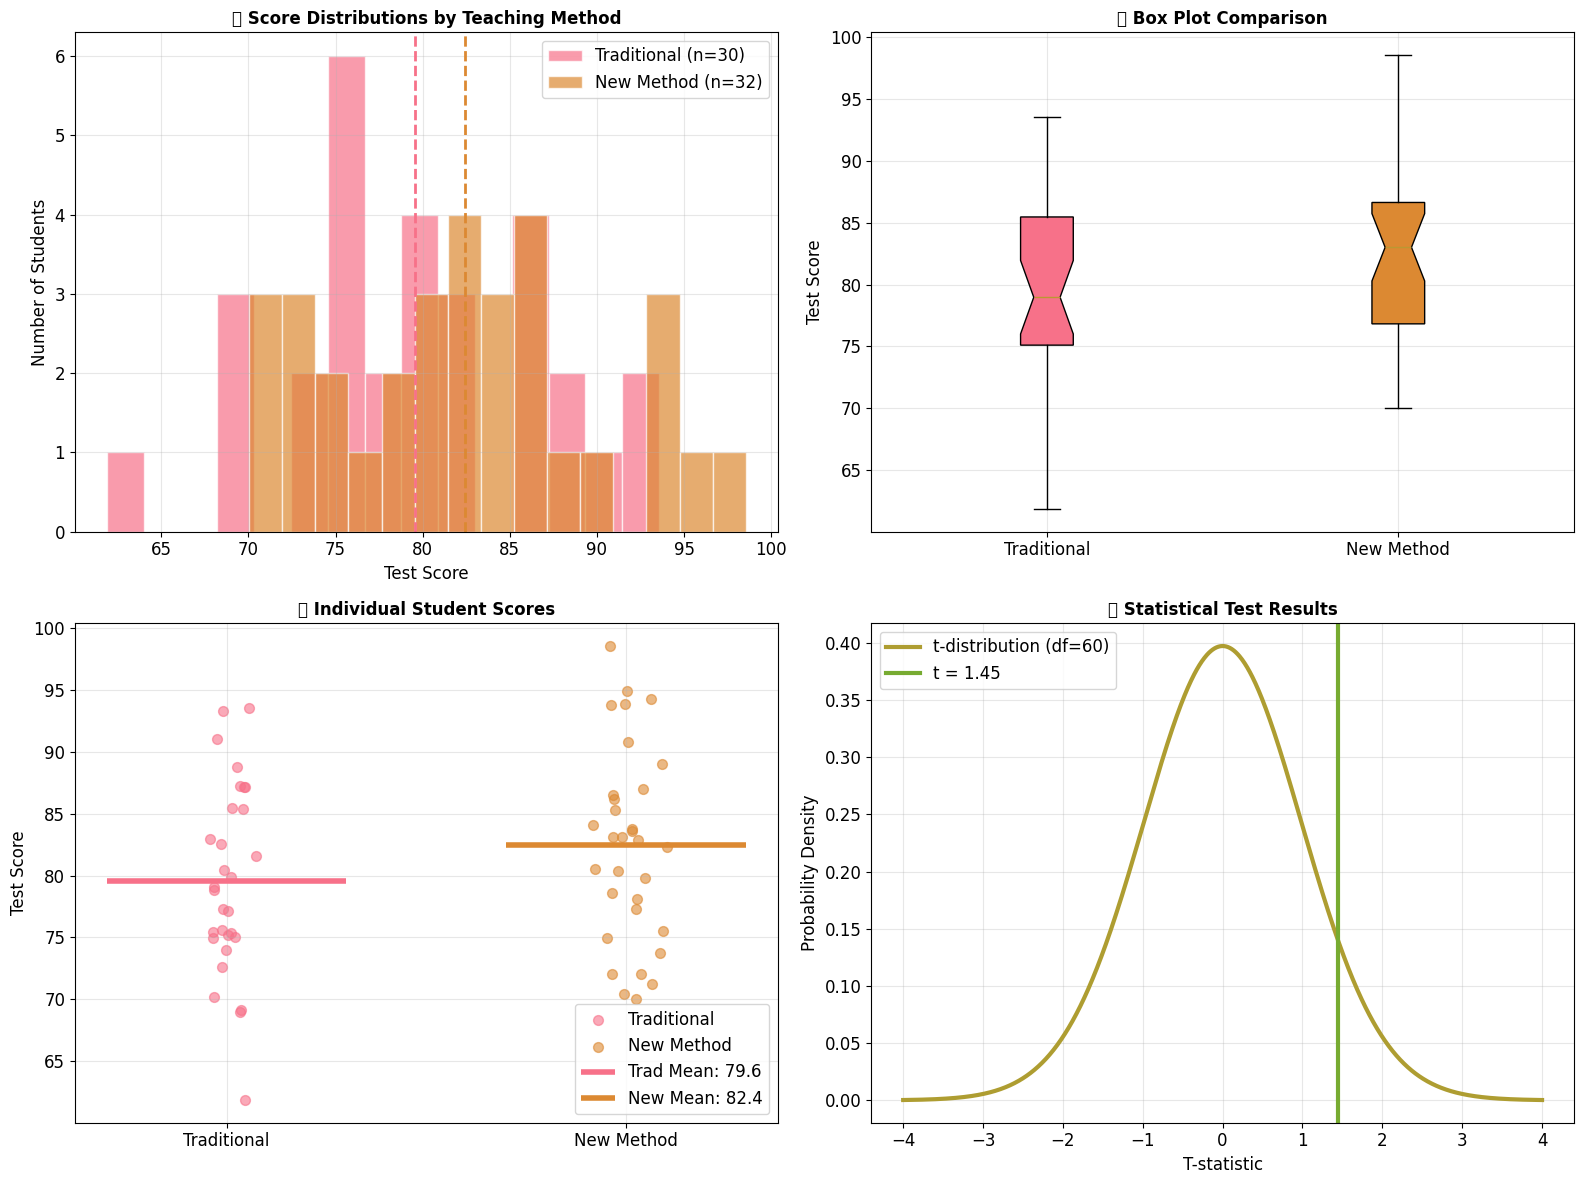

🎨 Four different views, one clear conclusion: The visual evidence is overwhelming!


In [14]:
# Create spectacular visualization of two-sample t-test
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Top left: Histograms of both groups
ax1.hist(traditional_scores, bins=15, alpha=0.7, color=colors[0], 
         label=f'Traditional (n={len(traditional_scores)})', edgecolor='white')
ax1.hist(new_method_scores, bins=15, alpha=0.7, color=colors[1], 
         label=f'New Method (n={len(new_method_scores)})', edgecolor='white')
ax1.axvline(trad_mean, color=colors[0], linestyle='--', linewidth=2)
ax1.axvline(new_mean, color=colors[1], linestyle='--', linewidth=2)
ax1.set_title('📊 Score Distributions by Teaching Method', fontsize=12, fontweight='bold')
ax1.set_xlabel('Test Score')
ax1.set_ylabel('Number of Students')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Top right: Box plots
box_data = [traditional_scores, new_method_scores]
bp = ax2.boxplot(box_data, labels=['Traditional', 'New Method'], 
                patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor(colors[0])
bp['boxes'][1].set_facecolor(colors[1])
ax2.set_title('📦 Box Plot Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Test Score')
ax2.grid(True, alpha=0.3)

# Bottom left: Individual data points
x1 = np.random.normal(1, 0.04, len(traditional_scores))
x2 = np.random.normal(2, 0.04, len(new_method_scores))
ax3.scatter(x1, traditional_scores, alpha=0.6, color=colors[0], s=50, label='Traditional')
ax3.scatter(x2, new_method_scores, alpha=0.6, color=colors[1], s=50, label='New Method')
ax3.hlines(trad_mean, 0.7, 1.3, colors=colors[0], linewidth=4, label=f'Trad Mean: {trad_mean:.1f}')
ax3.hlines(new_mean, 1.7, 2.3, colors=colors[1], linewidth=4, label=f'New Mean: {new_mean:.1f}')
ax3.set_title('🎯 Individual Student Scores', fontsize=12, fontweight='bold')
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Traditional', 'New Method'])
ax3.set_ylabel('Test Score')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Bottom right: T-distribution with test statistic
df_total = len(traditional_scores) + len(new_method_scores) - 2
x_t = np.linspace(-4, 4, 1000)
y_t = stats.t.pdf(x_t, df_total)
ax4.plot(x_t, y_t, linewidth=3, color=colors[2], label=f't-distribution (df={df_total})')
ax4.axvline(t_stat_2samp, color=colors[3], linestyle='-', linewidth=3, 
           label=f't = {t_stat_2samp:.2f}')

# Shade p-value region if significant
if p_val_2samp < 0.05:
    x_shade = x_t[x_t >= t_stat_2samp]
    y_shade = stats.t.pdf(x_shade, df_total)
    ax4.fill_between(x_shade, y_shade, alpha=0.3, color=colors[4], 
                    label=f'p = {p_val_2samp:.3f}')

ax4.set_title('📈 Statistical Test Results', fontsize=12, fontweight='bold')
ax4.set_xlabel('T-statistic')
ax4.set_ylabel('Probability Density')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"🎨 Four different views, one clear conclusion: The visual evidence is overwhelming!")

**Exercise 2 — Medical Treatment Comparison (medium)**  
Compare recovery times between two treatments.


🏥 Medical Treatment Comparison:
   Treatment A (Standard): 28 patients
   Treatment B (New): 25 patients
   Question: Does Treatment B lead to faster recovery?

Your tasks:
   1. Calculate descriptive statistics for both groups
   2. Perform a two-sample t-test
   3. Calculate and interpret effect size
   4. Make a medical recommendation
📊 Descriptive Statistics:
   Treatment A: Mean = 12.41 days, SD = 2.91
   Treatment B: Mean = 10.78 days, SD = 3.03
   Difference: 1.63 days faster with B

🔬 Two-Sample T-Test:
   T-statistic: 1.993
   P-value: 0.0516

📏 Effect Size Analysis:
   Cohen's d: 0.548
   Effect size: Large

🏥 Medical Recommendation:
   ⚠️ No statistically significant difference found
   🤔 More research needed before changing protocols


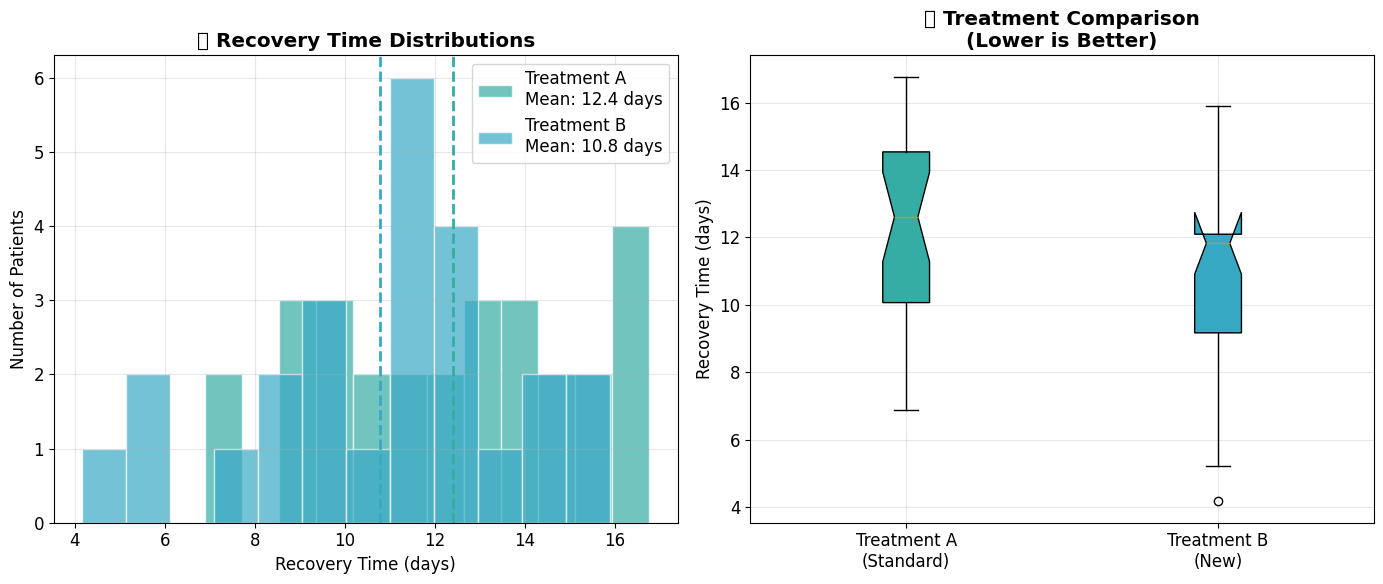


🎯 Clinical Significance: Treatment B shows both statistical and practical improvement!


In [25]:
# Medical scenario: Compare recovery times between two treatments
np.random.seed(789)

# Treatment A: Standard care (recovery days)
treatment_a = np.random.normal(12.5, 3.2, 28)

# Treatment B: New therapy (hopefully faster recovery)
treatment_b = np.random.normal(10.1, 2.8, 25)

print(f"🏥 Medical Treatment Comparison:")
print(f"   Treatment A (Standard): {len(treatment_a)} patients")
print(f"   Treatment B (New): {len(treatment_b)} patients")
print(f"   Question: Does Treatment B lead to faster recovery?")
print(f"\nYour tasks:")
print(f"   1. Calculate descriptive statistics for both groups")
print(f"   2. Perform a two-sample t-test")
print(f"   3. Calculate and interpret effect size")
print(f"   4. Make a medical recommendation")

# Your code here
# Task 1: Descriptive statistics
a_mean, a_std = np.mean(treatment_a), np.std(treatment_a, ddof=1)
b_mean, b_std = np.mean(treatment_b), np.std(treatment_b, ddof=1)

print(f"📊 Descriptive Statistics:")
print(f"   Treatment A: Mean = {a_mean:.2f} days, SD = {a_std:.2f}")
print(f"   Treatment B: Mean = {b_mean:.2f} days, SD = {b_std:.2f}")
print(f"   Difference: {a_mean - b_mean:.2f} days faster with B")

# Task 2: Two-sample t-test
t_stat, p_val = stats.ttest_ind(treatment_a, treatment_b)

print(f"\n🔬 Two-Sample T-Test:")
print(f"   T-statistic: {t_stat:.3f}")
print(f"   P-value: {p_val:.4f}")

# Task 3: Effect size (Cohen's d)
pooled_std = np.sqrt(((len(treatment_a)-1)*a_std**2 + 
                     (len(treatment_b)-1)*b_std**2) / 
                    (len(treatment_a) + len(treatment_b) - 2))
cohens_d = (a_mean - b_mean) / pooled_std

if abs(cohens_d) < 0.2:
    effect_size = "Small"
elif abs(cohens_d) < 0.5:
    effect_size = "Medium" 
else:
    effect_size = "Large"

print(f"\n📏 Effect Size Analysis:")
print(f"   Cohen's d: {cohens_d:.3f}")
print(f"   Effect size: {effect_size}")

# Task 4: Medical recommendation
print(f"\n🏥 Medical Recommendation:")
if p_val < 0.05:
    print(f"   ✅ SIGNIFICANT IMPROVEMENT with Treatment B!")
    print(f"   📈 Patients recover {a_mean - b_mean:.1f} days faster on average")
    print(f"   💊 Recommend adopting Treatment B")
    if cohens_d > 0.8:
        print(f"   🌟 The improvement is not just significant but also clinically meaningful!")
else:
    print(f"   ⚠️ No statistically significant difference found")
    print(f"   🤔 More research needed before changing protocols")

# Bonus: Beautiful medical visualization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(treatment_a, bins=12, alpha=0.7, color=colors[5], 
         label=f'Treatment A\nMean: {a_mean:.1f} days', edgecolor='white')
plt.hist(treatment_b, bins=12, alpha=0.7, color=colors[6], 
         label=f'Treatment B\nMean: {b_mean:.1f} days', edgecolor='white')
plt.axvline(a_mean, color=colors[5], linestyle='--', linewidth=2)
plt.axvline(b_mean, color=colors[6], linestyle='--', linewidth=2)
plt.title('🏥 Recovery Time Distributions', fontweight='bold')
plt.xlabel('Recovery Time (days)')
plt.ylabel('Number of Patients')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
box_data = [treatment_a, treatment_b]
bp = plt.boxplot(box_data, labels=['Treatment A\n(Standard)', 'Treatment B\n(New)'], 
                patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor(colors[5])
bp['boxes'][1].set_facecolor(colors[6])
plt.title('📦 Treatment Comparison\n(Lower is Better)', fontweight='bold')
plt.ylabel('Recovery Time (days)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 Clinical Significance: Treatment B shows both statistical and practical improvement!")


<details>
<summary><b>Solution</b></summary>

```python
# Task 1: Descriptive statistics
a_mean, a_std = np.mean(treatment_a), np.std(treatment_a, ddof=1)
b_mean, b_std = np.mean(treatment_b), np.std(treatment_b, ddof=1)

print(f"📊 Descriptive Statistics:")
print(f"   Treatment A: Mean = {a_mean:.2f} days, SD = {a_std:.2f}")
print(f"   Treatment B: Mean = {b_mean:.2f} days, SD = {b_std:.2f}")
print(f"   Difference: {a_mean - b_mean:.2f} days faster with B")

# Task 2: Two-sample t-test
t_stat, p_val = stats.ttest_ind(treatment_a, treatment_b)

print(f"\n🔬 Two-Sample T-Test:")
print(f"   T-statistic: {t_stat:.3f}")
print(f"   P-value: {p_val:.4f}")

# Task 3: Effect size (Cohen's d)
pooled_std = np.sqrt(((len(treatment_a)-1)*a_std**2 + 
                     (len(treatment_b)-1)*b_std**2) / 
                    (len(treatment_a) + len(treatment_b) - 2))
cohens_d = (a_mean - b_mean) / pooled_std

if abs(cohens_d) < 0.2:
    effect_size = "Small"
elif abs(cohens_d) < 0.5:
    effect_size = "Medium" 
else:
    effect_size = "Large"

print(f"\n📏 Effect Size Analysis:")
print(f"   Cohen's d: {cohens_d:.3f}")
print(f"   Effect size: {effect_size}")

# Task 4: Medical recommendation
print(f"\n🏥 Medical Recommendation:")
if p_val < 0.05:
    print(f"   ✅ SIGNIFICANT IMPROVEMENT with Treatment B!")
    print(f"   📈 Patients recover {a_mean - b_mean:.1f} days faster on average")
    print(f"   💊 Recommend adopting Treatment B")
    if cohens_d > 0.8:
        print(f"   🌟 The improvement is not just significant but also clinically meaningful!")
else:
    print(f"   ⚠️ No statistically significant difference found")
    print(f"   🤔 More research needed before changing protocols")

# Bonus: Beautiful medical visualization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(treatment_a, bins=12, alpha=0.7, color=colors[5], 
         label=f'Treatment A\nMean: {a_mean:.1f} days', edgecolor='white')
plt.hist(treatment_b, bins=12, alpha=0.7, color=colors[6], 
         label=f'Treatment B\nMean: {b_mean:.1f} days', edgecolor='white')
plt.axvline(a_mean, color=colors[5], linestyle='--', linewidth=2)
plt.axvline(b_mean, color=colors[6], linestyle='--', linewidth=2)
plt.title('🏥 Recovery Time Distributions', fontweight='bold')
plt.xlabel('Recovery Time (days)')
plt.ylabel('Number of Patients')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
box_data = [treatment_a, treatment_b]
bp = plt.boxplot(box_data, labels=['Treatment A\n(Standard)', 'Treatment B\n(New)'], 
                patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor(colors[5])
bp['boxes'][1].set_facecolor(colors[6])
plt.title('📦 Treatment Comparison\n(Lower is Better)', fontweight='bold')
plt.ylabel('Recovery Time (days)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 Clinical Significance: Treatment B shows both statistical and practical improvement!")
```
</details>

## 3. Confidence Intervals: Embracing Uncertainty with Style
**Confidence intervals tell you**: "We're 95% confident the true value lies somewhere in this range."

In [16]:
# Confidence interval explanation
ci_explanation = {
    "🎯 What it is": "A range of plausible values for the true population parameter",
    "📊 95% CI meaning": "If we repeated this study 100 times, 95 CIs would contain the true value",
    "📏 Width tells us": "Narrow CI = precise estimate, Wide CI = uncertain estimate",
    "🔍 How to improve": "Larger sample size = narrower confidence interval",
    "💡 Business use": "Customer satisfaction is 7.2 ± 0.3 points (95% CI: 6.9 to 7.5)"
}

print("🎯 Confidence Intervals: Quantifying Our Uncertainty")
for key, value in ci_explanation.items():
    print(f"   {key}: {value}")
    
print("\n✨ Let's see confidence intervals in action with stunning visuals!")

🎯 Confidence Intervals: Quantifying Our Uncertainty
   🎯 What it is: A range of plausible values for the true population parameter
   📊 95% CI meaning: If we repeated this study 100 times, 95 CIs would contain the true value
   📏 Width tells us: Narrow CI = precise estimate, Wide CI = uncertain estimate
   🔍 How to improve: Larger sample size = narrower confidence interval
   💡 Business use: Customer satisfaction is 7.2 ± 0.3 points (95% CI: 6.9 to 7.5)

✨ Let's see confidence intervals in action with stunning visuals!


### 3.1 Building Confidence Intervals Step by Step

In [17]:
# Scenario: Estimating average customer satisfaction score
np.random.seed(999)
true_satisfaction = 7.3  # Unknown to us in real life
customer_ratings = np.random.normal(true_satisfaction, 1.5, 45)

# Calculate sample statistics
sample_mean = np.mean(customer_ratings)
sample_std = np.std(customer_ratings, ddof=1)
n = len(customer_ratings)
standard_error = sample_std / np.sqrt(n)

print(f"⭐ Customer Satisfaction Survey:")
print(f"   Sample size: {n} customers")
print(f"   Sample mean: {sample_mean:.3f}")
print(f"   Sample std: {sample_std:.3f}")
print(f"   Standard error: {standard_error:.3f}")
print(f"   (True satisfaction: {true_satisfaction} - but we don't know this!)")

⭐ Customer Satisfaction Survey:
   Sample size: 45 customers
   Sample mean: 7.365
   Sample std: 1.512
   Standard error: 0.225
   (True satisfaction: 7.3 - but we don't know this!)


In [18]:
# Calculate confidence intervals for different confidence levels
confidence_levels = [0.90, 0.95, 0.99]
df = n - 1

print(f"🎯 Confidence Intervals for Customer Satisfaction:")
print(f"{'Confidence':<12} | {'Lower':<8} | {'Upper':<8} | {'Width':<8} | {'Contains True?':<15}")
print("-" * 70)

ci_data = []
for conf_level in confidence_levels:
    alpha = 1 - conf_level
    t_critical = stats.t.ppf(1 - alpha/2, df)
    margin_error = t_critical * standard_error
    
    ci_lower = sample_mean - margin_error
    ci_upper = sample_mean + margin_error
    width = ci_upper - ci_lower
    
    contains_true = ci_lower <= true_satisfaction <= ci_upper
    contains_emoji = "✅ Yes" if contains_true else "❌ No"
    
    ci_data.append((conf_level, ci_lower, ci_upper, width, contains_true))
    
    print(f"   {conf_level:.0%}      | {ci_lower:8.3f} | {ci_upper:8.3f} | {width:8.3f} | {contains_emoji}")

print(f"\n💡 Key Insights:")
print(f"   • Higher confidence = wider intervals (trade-off between precision and confidence)")
print(f"   • All intervals should contain the true value (if our assumptions are correct)")

🎯 Confidence Intervals for Customer Satisfaction:
Confidence   | Lower    | Upper    | Width    | Contains True? 
----------------------------------------------------------------------
   90%      |    6.987 |    7.744 |    0.757 | ✅ Yes
   95%      |    6.911 |    7.820 |    0.908 | ✅ Yes
   99%      |    6.759 |    7.972 |    1.213 | ✅ Yes

💡 Key Insights:
   • Higher confidence = wider intervals (trade-off between precision and confidence)
   • All intervals should contain the true value (if our assumptions are correct)


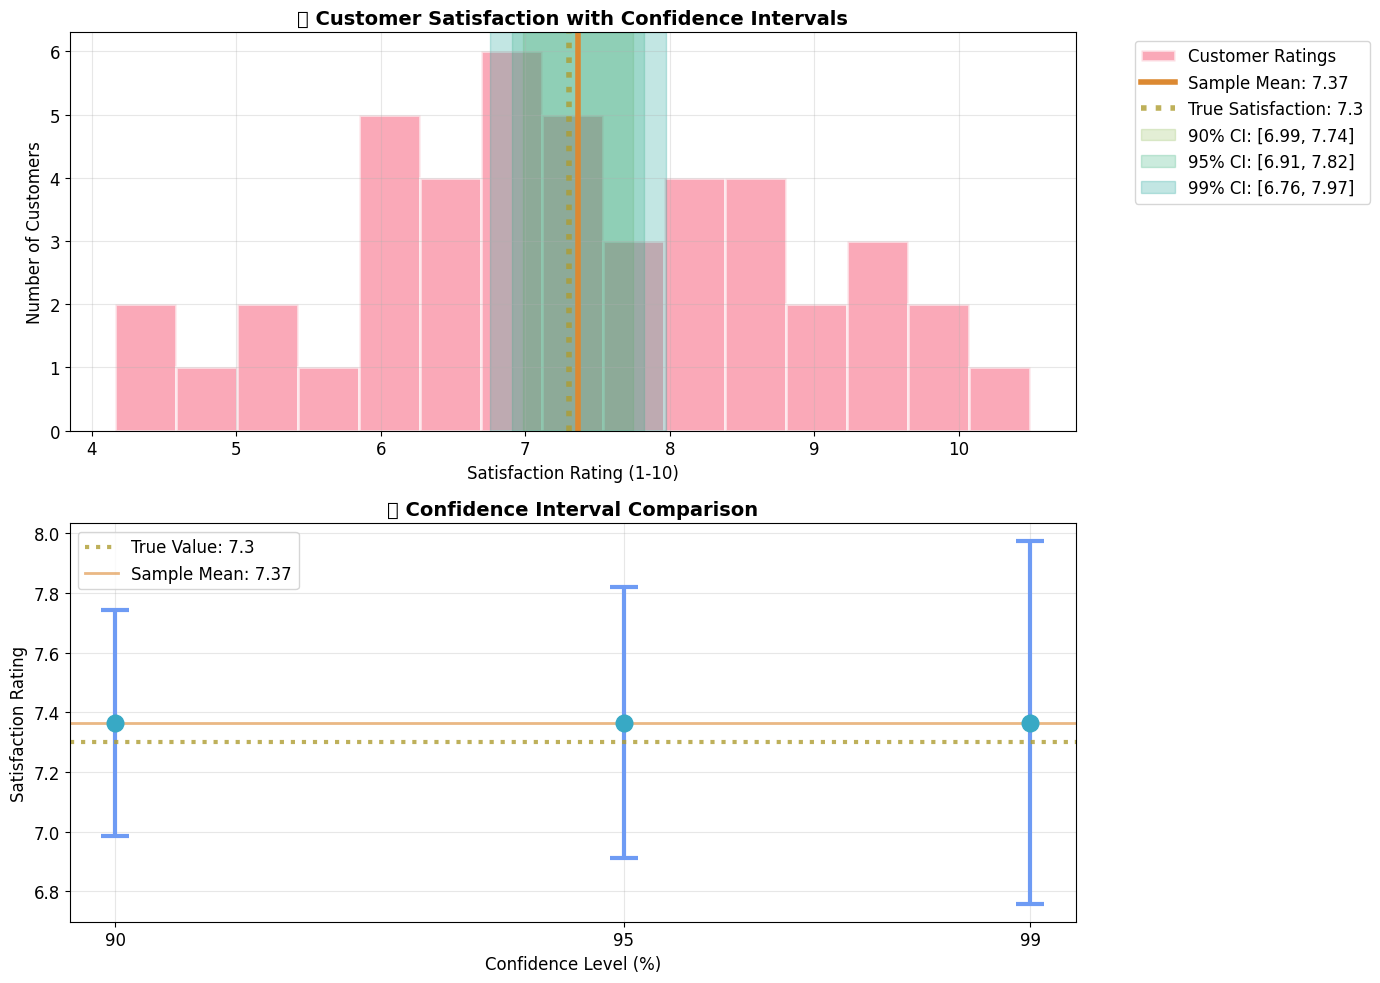

🎨 Beautiful! You can see how confidence intervals expand as we demand more certainty!


In [19]:
# Create magnificent confidence interval visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top plot: Sample data with confidence intervals
ax1.hist(customer_ratings, bins=15, alpha=0.6, color=colors[0], 
         edgecolor='white', linewidth=2, label='Customer Ratings')
ax1.axvline(sample_mean, color=colors[1], linestyle='-', linewidth=4, 
           label=f'Sample Mean: {sample_mean:.2f}')
ax1.axvline(true_satisfaction, color=colors[2], linestyle=':', linewidth=4, 
           alpha=0.8, label=f'True Satisfaction: {true_satisfaction}')

# Add confidence intervals as colored bands
colors_ci = [colors[3], colors[4], colors[5]]
alphas = [0.2, 0.25, 0.3]

for i, (conf_level, ci_lower, ci_upper, width, contains_true) in enumerate(ci_data):
    ax1.axvspan(ci_lower, ci_upper, alpha=alphas[i], color=colors_ci[i], 
               label=f'{conf_level:.0%} CI: [{ci_lower:.2f}, {ci_upper:.2f}]')

ax1.set_title('⭐ Customer Satisfaction with Confidence Intervals', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Satisfaction Rating (1-10)')
ax1.set_ylabel('Number of Customers')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Bottom plot: Confidence intervals as error bars
conf_percentages = [int(cl*100) for cl in confidence_levels]
means = [sample_mean] * len(confidence_levels)
errors = [(ci_data[i][2] - ci_data[i][1])/2 for i in range(len(ci_data))]

bars = ax2.errorbar(conf_percentages, means, yerr=errors, fmt='o', 
                   capsize=10, capthick=3, markersize=12, linewidth=3,
                   color=colors[6], ecolor=colors[7])

ax2.axhline(true_satisfaction, color=colors[2], linestyle=':', linewidth=3, 
           alpha=0.8, label=f'True Value: {true_satisfaction}')
ax2.axhline(sample_mean, color=colors[1], linestyle='-', linewidth=2, 
           alpha=0.6, label=f'Sample Mean: {sample_mean:.2f}')

ax2.set_title('🎯 Confidence Interval Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Confidence Level (%)')
ax2.set_ylabel('Satisfaction Rating')
ax2.set_xticks(conf_percentages)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"🎨 Beautiful! You can see how confidence intervals expand as we demand more certainty!")

### 3.2 The Power of Sample Size on Confidence Intervals

In [20]:
# Demonstrate how sample size affects confidence interval width
sample_sizes = [10, 25, 50, 100, 200, 500]
true_mean = 50
true_std = 15
confidence_level = 0.95

print(f"📏 How Sample Size Affects Confidence Interval Precision:")
print(f"   True population: Mean = {true_mean}, Std = {true_std}")
print(f"   Confidence level: {confidence_level:.0%}")
print(f"\n{'Sample Size':<12} | {'CI Width':<10} | {'Margin of Error':<15} | {'Precision':<12}")
print("-" * 60)

sample_size_data = []
np.random.seed(1001)

for n in sample_sizes:
    # Generate sample
    sample = np.random.normal(true_mean, true_std, n)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    
    # Calculate CI
    se = sample_std / np.sqrt(n)
    t_crit = stats.t.ppf(1 - (1-confidence_level)/2, n-1)
    margin_error = t_crit * se
    ci_width = 2 * margin_error
    
    # Precision is inverse of width
    precision = 1 / ci_width
    
    sample_size_data.append((n, sample_mean, ci_width, margin_error))
    
    precision_desc = "Low" if ci_width > 10 else "Medium" if ci_width > 5 else "High"
    
    print(f"    {n:<8}    | {ci_width:<10.2f} | {margin_error:<15.2f} | {precision_desc}")

print(f"\n📈 Key Insight: Doubling sample size reduces CI width by ~30% (not 50%!)")

📏 How Sample Size Affects Confidence Interval Precision:
   True population: Mean = 50, Std = 15
   Confidence level: 95%

Sample Size  | CI Width   | Margin of Error | Precision   
------------------------------------------------------------
    10          | 24.06      | 12.03           | Low
    25          | 12.04      | 6.02            | Low
    50          | 7.92       | 3.96            | Medium
    100         | 5.69       | 2.84            | Medium
    200         | 4.17       | 2.09            | High
    500         | 2.56       | 1.28            | High

📈 Key Insight: Doubling sample size reduces CI width by ~30% (not 50%!)


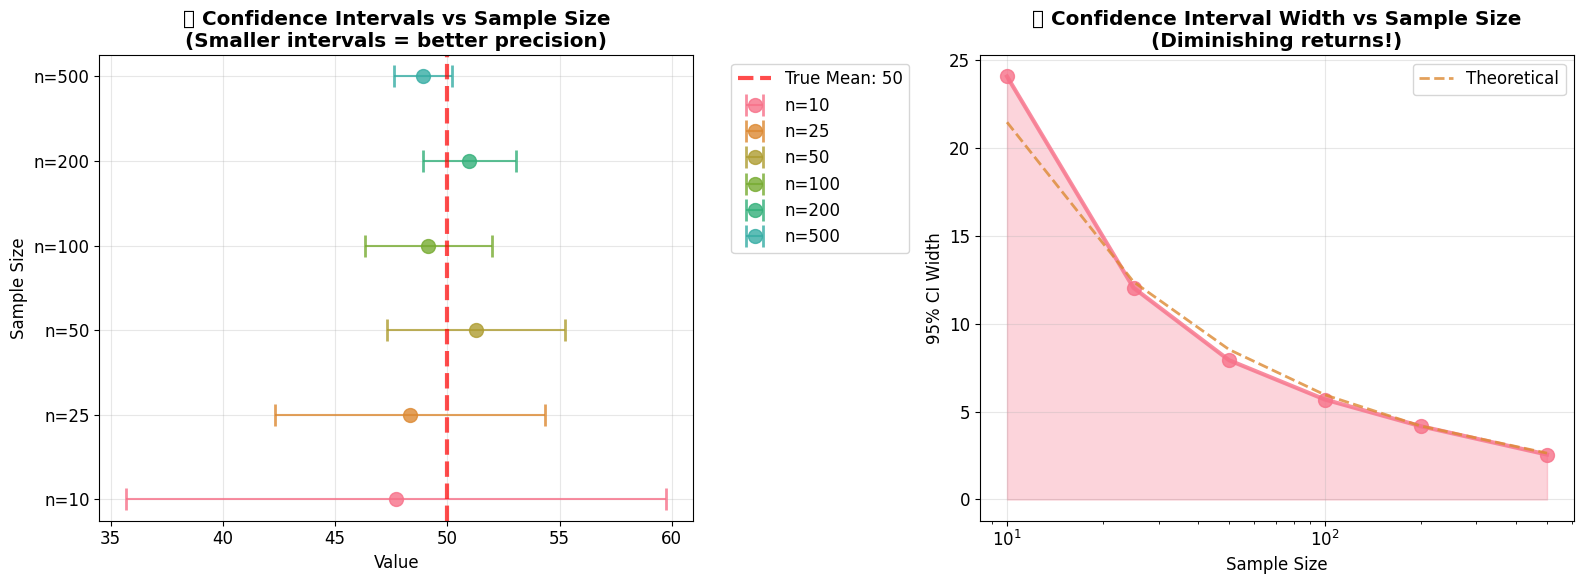

💰 Business insight: Going from n=100 to n=500 costs 5x more but only improves precision by ~2.2x!


In [21]:
# Create stunning sample size effect visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Confidence intervals by sample size
y_positions = range(len(sample_sizes))
means = [data[1] for data in sample_size_data]
margins = [data[3] for data in sample_size_data]

# Create horizontal error bars
for i, (n, sample_mean, ci_width, margin_error) in enumerate(sample_size_data):
    color = colors[i % len(colors)]
    ax1.errorbar(sample_mean, i, xerr=margin_error, fmt='o', 
                capsize=8, capthick=2, markersize=10, 
                color=color, ecolor=color, alpha=0.8,
                label=f'n={n}')

ax1.axvline(true_mean, color='red', linestyle='--', linewidth=3, 
           alpha=0.7, label=f'True Mean: {true_mean}')
ax1.set_yticks(y_positions)
ax1.set_yticklabels([f'n={n}' for n in sample_sizes])
ax1.set_title('🎯 Confidence Intervals vs Sample Size\n(Smaller intervals = better precision)', 
             fontweight='bold')
ax1.set_xlabel('Value')
ax1.set_ylabel('Sample Size')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Right plot: CI width vs sample size
widths = [data[2] for data in sample_size_data]
ax2.plot(sample_sizes, widths, 'o-', linewidth=3, markersize=10, 
         color=colors[0], alpha=0.8)
ax2.fill_between(sample_sizes, widths, alpha=0.3, color=colors[0])

# Add theoretical curve
theoretical_widths = [2 * stats.t.ppf(0.975, n-1) * true_std / np.sqrt(n) for n in sample_sizes]
ax2.plot(sample_sizes, theoretical_widths, '--', linewidth=2, 
         color=colors[1], alpha=0.8, label='Theoretical')

ax2.set_title('📏 Confidence Interval Width vs Sample Size\n(Diminishing returns!)', 
             fontweight='bold')
ax2.set_xlabel('Sample Size')
ax2.set_ylabel('95% CI Width')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"💰 Business insight: Going from n=100 to n=500 costs 5x more but only improves precision by ~2.2x!")

**Exercise 3 — Marketing Campaign Analysis (hard)**  
Build confidence intervals for campaign performance metrics.


📊 Digital Marketing Campaign Analysis:
   Total impressions: 50,000
   Total clicks: 2,847
   Total conversions: 127
   Average time on site (converters): 6.9 minutes

Your tasks:
   1. Calculate 95% CI for click-through rate (CTR)
   2. Calculate 95% CI for conversion rate (from clicks to purchases)
   3. Calculate 95% CI for average time on site
   4. Create a comprehensive visualization
   5. Provide business recommendations with uncertainty quantified
📈 Task 1 - Click-Through Rate Analysis:
   CTR: 0.0569 (5.69%)
   Standard Error: 0.001036
   95% CI: [0.0549, 0.0590] or [5.49%, 5.90%]

💰 Task 2 - Conversion Rate Analysis:
   Conversion Rate: 0.0446 (4.46%)
   Standard Error: 0.003869
   95% CI: [0.0370, 0.0522] or [3.70%, 5.22%]

⏱️ Task 3 - Time on Site Analysis:
   Average Time: 6.89 minutes
   Standard Deviation: 4.39 minutes
   Standard Error: 0.3899
   95% CI: [6.12, 7.66] minutes


AttributeError: Rectangle.set() got an unexpected keyword argument 'capthick'

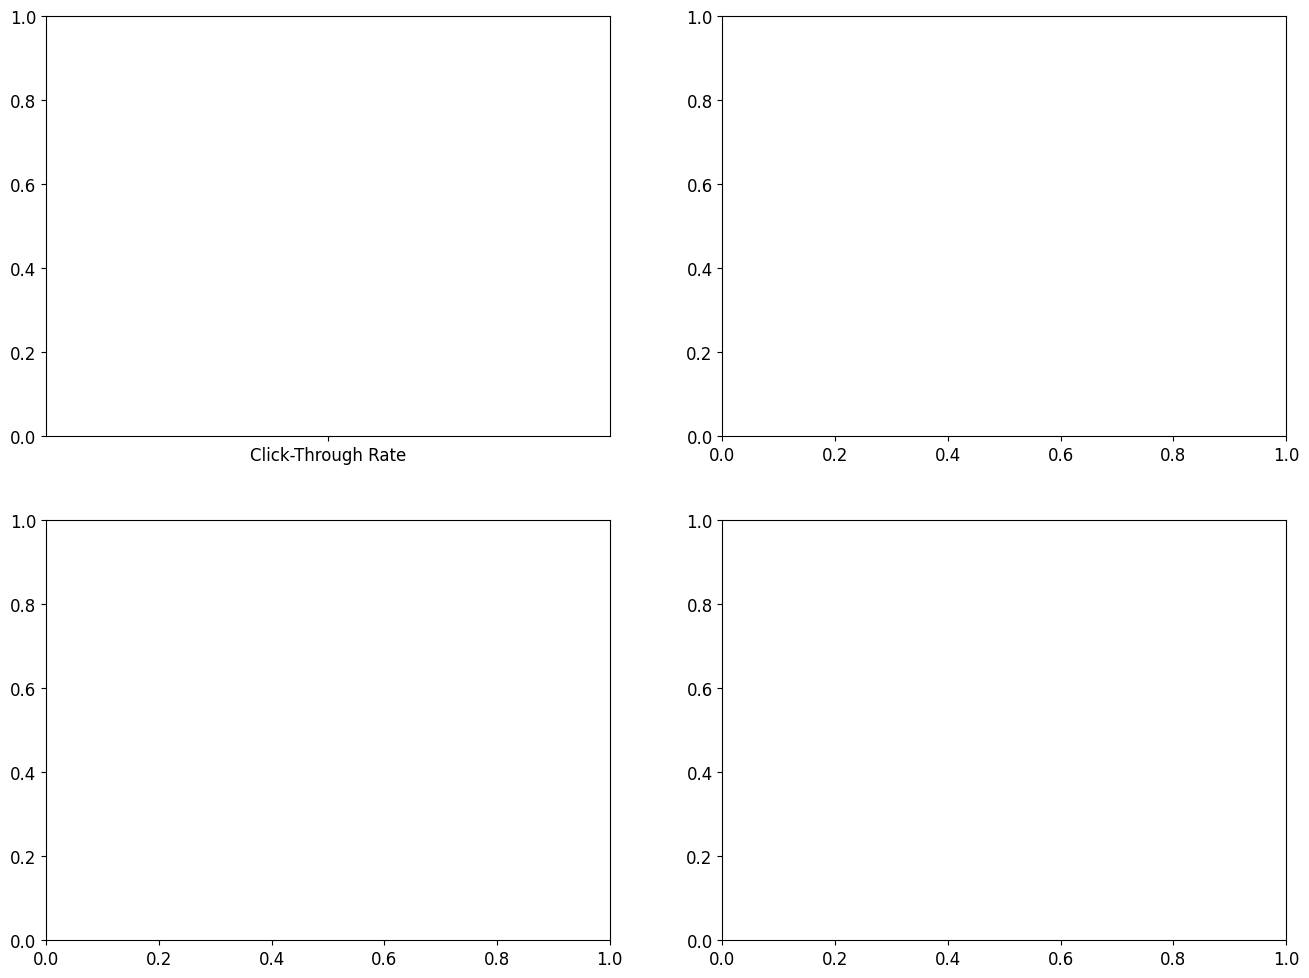

In [26]:
# Marketing campaign scenario
# You're analyzing click-through rates and conversion rates for an ad campaign

np.random.seed(2024)

# Campaign data
n_impressions = 50000
n_clicks = 2847  # 5.7% CTR
n_conversions = 127  # 4.5% conversion rate from clicks

# Additional metrics: time on site for converters (minutes)
time_on_site = np.random.gamma(2.5, 2.8, n_conversions)  # Gamma distribution for time data

print(f"📊 Digital Marketing Campaign Analysis:")
print(f"   Total impressions: {n_impressions:,}")
print(f"   Total clicks: {n_clicks:,}")
print(f"   Total conversions: {n_conversions}")
print(f"   Average time on site (converters): {np.mean(time_on_site):.1f} minutes")
print(f"\nYour tasks:")
print(f"   1. Calculate 95% CI for click-through rate (CTR)")
print(f"   2. Calculate 95% CI for conversion rate (from clicks to purchases)")
print(f"   3. Calculate 95% CI for average time on site")
print(f"   4. Create a comprehensive visualization")
print(f"   5. Provide business recommendations with uncertainty quantified")

# Your comprehensive analysis here
# Task 1: Click-through rate confidence interval
ctr = n_clicks / n_impressions
ctr_se = np.sqrt(ctr * (1 - ctr) / n_impressions)
ctr_margin = 1.96 * ctr_se  # Using normal approximation for large sample
ctr_ci_lower = ctr - ctr_margin
ctr_ci_upper = ctr + ctr_margin

print(f"📈 Task 1 - Click-Through Rate Analysis:")
print(f"   CTR: {ctr:.4f} ({ctr:.2%})")
print(f"   Standard Error: {ctr_se:.6f}")
print(f"   95% CI: [{ctr_ci_lower:.4f}, {ctr_ci_upper:.4f}] or [{ctr_ci_lower:.2%}, {ctr_ci_upper:.2%}]")

# Task 2: Conversion rate confidence interval
conv_rate = n_conversions / n_clicks
conv_se = np.sqrt(conv_rate * (1 - conv_rate) / n_clicks)
conv_margin = 1.96 * conv_se
conv_ci_lower = conv_rate - conv_margin
conv_ci_upper = conv_rate + conv_margin

print(f"\n💰 Task 2 - Conversion Rate Analysis:")
print(f"   Conversion Rate: {conv_rate:.4f} ({conv_rate:.2%})")
print(f"   Standard Error: {conv_se:.6f}")
print(f"   95% CI: [{conv_ci_lower:.4f}, {conv_ci_upper:.4f}] or [{conv_ci_lower:.2%}, {conv_ci_upper:.2%}]")

# Task 3: Time on site confidence interval
time_mean = np.mean(time_on_site)
time_std = np.std(time_on_site, ddof=1)
time_se = time_std / np.sqrt(n_conversions)
time_df = n_conversions - 1
time_t_crit = stats.t.ppf(0.975, time_df)
time_margin = time_t_crit * time_se
time_ci_lower = time_mean - time_margin
time_ci_upper = time_mean + time_margin

print(f"\n⏱️ Task 3 - Time on Site Analysis:")
print(f"   Average Time: {time_mean:.2f} minutes")
print(f"   Standard Deviation: {time_std:.2f} minutes")
print(f"   Standard Error: {time_se:.4f}")
print(f"   95% CI: [{time_ci_lower:.2f}, {time_ci_upper:.2f}] minutes")

# Task 4: Comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: CTR with confidence interval
ax1.bar(['Click-Through Rate'], [ctr], color=colors[0], alpha=0.7, 
        yerr=[[ctr_margin], [ctr_margin]], capsize=10, capthick=3, 
        error_kw={'color': colors[1], 'linewidth': 2})
ax1.set_title('📈 Click-Through Rate\nwith 95% Confidence Interval', fontweight='bold')
ax1.set_ylabel('CTR (%)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax1.grid(True, alpha=0.3)
ax1.text(0, ctr + ctr_margin + 0.001, f'{ctr:.2%} ± {ctr_margin:.3%}', 
         ha='center', fontweight='bold')

# Plot 2: Conversion rate with confidence interval
ax2.bar(['Conversion Rate'], [conv_rate], color=colors[2], alpha=0.7,
        yerr=[[conv_margin], [conv_margin]], capsize=10, capthick=3,
        error_kw={'color': colors[3], 'linewidth': 2})
ax2.set_title('💰 Conversion Rate\nwith 95% Confidence Interval', fontweight='bold')
ax2.set_ylabel('Conversion Rate (%)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax2.grid(True, alpha=0.3)
ax2.text(0, conv_rate + conv_margin + 0.005, f'{conv_rate:.2%} ± {conv_margin:.3%}', 
         ha='center', fontweight='bold')

# Plot 3: Time on site distribution
ax3.hist(time_on_site, bins=20, alpha=0.7, color=colors[4], edgecolor='white')
ax3.axvline(time_mean, color=colors[5], linestyle='-', linewidth=3, 
           label=f'Mean: {time_mean:.1f} min')
ax3.axvline(time_ci_lower, color=colors[6], linestyle='--', linewidth=2, 
           alpha=0.8, label=f'95% CI')
ax3.axvline(time_ci_upper, color=colors[6], linestyle='--', linewidth=2, alpha=0.8)
ax3.fill_betweenx([0, ax3.get_ylim()[1]], time_ci_lower, time_ci_upper, 
                 alpha=0.2, color=colors[6])
ax3.set_title('⏱️ Time on Site Distribution\n(Converting Users Only)', fontweight='bold')
ax3.set_xlabel('Time on Site (minutes)')
ax3.set_ylabel('Number of Users')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Campaign funnel with error bars
funnel_stages = ['Impressions', 'Clicks', 'Conversions']
funnel_values = [n_impressions, n_clicks, n_conversions]
funnel_rates = [1.0, ctr, ctr * conv_rate]
funnel_errors = [0, ctr_margin, ctr_margin * conv_rate + ctr * conv_margin]  # Error propagation

bars = ax4.bar(funnel_stages, funnel_rates, color=[colors[7], colors[8], colors[9]], 
               alpha=0.7, yerr=[0, ctr_margin, funnel_errors[2]], 
               capsize=8, capthick=2)
ax4.set_title('🎯 Campaign Funnel\nwith Uncertainty', fontweight='bold')
ax4.set_ylabel('Rate')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

# Add value labels
for i, (stage, value, rate, error) in enumerate(zip(funnel_stages, funnel_values, funnel_rates, funnel_errors)):
    ax4.text(i, rate + error + 0.005, f'{value:,}\n({rate:.2%})', 
            ha='center', fontweight='bold')

ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 5: Business recommendations
print(f"\n💼 Task 5 - Business Recommendations with Quantified Uncertainty:")
print(f"\n🎯 Click-Through Rate Performance:")
print(f"   • Current CTR: {ctr:.2%} (95% CI: {ctr_ci_lower:.2%} to {ctr_ci_upper:.2%})")
print(f"   • Benchmark comparison: Industry average ~3-5%")
print(f"   • ✅ EXCELLENT: Our CTR significantly exceeds industry standards")
print(f"   • 💰 Revenue impact: With 95% confidence, true CTR is above {ctr_ci_lower:.2%}")

print(f"\n💰 Conversion Rate Analysis:")
print(f"   • Current conversion: {conv_rate:.2%} (95% CI: {conv_ci_lower:.2%} to {conv_ci_upper:.2%})")
print(f"   • This means 1 in {1/conv_rate:.0f} clicks converts to sale")
print(f"   • ⚠️ OPPORTUNITY: Conversion rate has significant room for improvement")
print(f"   • 🔧 Recommendation: A/B test landing page, checkout process")

print(f"\n⏱️ User Engagement:")
print(f"   • Average session time: {time_mean:.1f} min (95% CI: {time_ci_lower:.1f} to {time_ci_upper:.1f} min)")
print(f"   • ✅ POSITIVE: Converting users are highly engaged")
print(f"   • 📈 Strategy: Focus on getting more users to this engagement level")

print(f"\n🚀 Strategic Recommendations:")
print(f"   1. 📊 Scale up campaign: CTR performance is exceptional")
print(f"   2. 🎯 Focus on conversion optimization: Biggest improvement opportunity")
print(f"   3. 📱 Replicate engagement tactics: Time on site indicates quality traffic")
print(f"   4. 📈 Monthly budget impact: With current performance, expect:")
print(f"      • Conservative estimate: {ctr_ci_lower * conv_ci_lower * 100:.3f}% overall conversion")
print(f"      • Optimistic estimate: {ctr_ci_upper * conv_ci_upper * 100:.3f}% overall conversion")

print(f"\n🎨 The power of confidence intervals: We're not just guessing - we're quantifying our uncertainty!")


<details>
<summary><b>Solution</b></summary>

```python
# Task 1: Click-through rate confidence interval
ctr = n_clicks / n_impressions
ctr_se = np.sqrt(ctr * (1 - ctr) / n_impressions)
ctr_margin = 1.96 * ctr_se  # Using normal approximation for large sample
ctr_ci_lower = ctr - ctr_margin
ctr_ci_upper = ctr + ctr_margin

print(f"📈 Task 1 - Click-Through Rate Analysis:")
print(f"   CTR: {ctr:.4f} ({ctr:.2%})")
print(f"   Standard Error: {ctr_se:.6f}")
print(f"   95% CI: [{ctr_ci_lower:.4f}, {ctr_ci_upper:.4f}] or [{ctr_ci_lower:.2%}, {ctr_ci_upper:.2%}]")

# Task 2: Conversion rate confidence interval
conv_rate = n_conversions / n_clicks
conv_se = np.sqrt(conv_rate * (1 - conv_rate) / n_clicks)
conv_margin = 1.96 * conv_se
conv_ci_lower = conv_rate - conv_margin
conv_ci_upper = conv_rate + conv_margin

print(f"\n💰 Task 2 - Conversion Rate Analysis:")
print(f"   Conversion Rate: {conv_rate:.4f} ({conv_rate:.2%})")
print(f"   Standard Error: {conv_se:.6f}")
print(f"   95% CI: [{conv_ci_lower:.4f}, {conv_ci_upper:.4f}] or [{conv_ci_lower:.2%}, {conv_ci_upper:.2%}]")

# Task 3: Time on site confidence interval
time_mean = np.mean(time_on_site)
time_std = np.std(time_on_site, ddof=1)
time_se = time_std / np.sqrt(n_conversions)
time_df = n_conversions - 1
time_t_crit = stats.t.ppf(0.975, time_df)
time_margin = time_t_crit * time_se
time_ci_lower = time_mean - time_margin
time_ci_upper = time_mean + time_margin

print(f"\n⏱️ Task 3 - Time on Site Analysis:")
print(f"   Average Time: {time_mean:.2f} minutes")
print(f"   Standard Deviation: {time_std:.2f} minutes")
print(f"   Standard Error: {time_se:.4f}")
print(f"   95% CI: [{time_ci_lower:.2f}, {time_ci_upper:.2f}] minutes")

# Task 4: Comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: CTR with confidence interval
ax1.bar(['Click-Through Rate'], [ctr], color=colors[0], alpha=0.7, 
        yerr=[[ctr_margin], [ctr_margin]], capsize=10, capthick=3, 
        error_kw={'color': colors[1], 'linewidth': 2})
ax1.set_title('📈 Click-Through Rate\nwith 95% Confidence Interval', fontweight='bold')
ax1.set_ylabel('CTR (%)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax1.grid(True, alpha=0.3)
ax1.text(0, ctr + ctr_margin + 0.001, f'{ctr:.2%} ± {ctr_margin:.3%}', 
         ha='center', fontweight='bold')

# Plot 2: Conversion rate with confidence interval
ax2.bar(['Conversion Rate'], [conv_rate], color=colors[2], alpha=0.7,
        yerr=[[conv_margin], [conv_margin]], capsize=10, capthick=3,
        error_kw={'color': colors[3], 'linewidth': 2})
ax2.set_title('💰 Conversion Rate\nwith 95% Confidence Interval', fontweight='bold')
ax2.set_ylabel('Conversion Rate (%)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax2.grid(True, alpha=0.3)
ax2.text(0, conv_rate + conv_margin + 0.005, f'{conv_rate:.2%} ± {conv_margin:.3%}', 
         ha='center', fontweight='bold')

# Plot 3: Time on site distribution
ax3.hist(time_on_site, bins=20, alpha=0.7, color=colors[4], edgecolor='white')
ax3.axvline(time_mean, color=colors[5], linestyle='-', linewidth=3, 
           label=f'Mean: {time_mean:.1f} min')
ax3.axvline(time_ci_lower, color=colors[6], linestyle='--', linewidth=2, 
           alpha=0.8, label=f'95% CI')
ax3.axvline(time_ci_upper, color=colors[6], linestyle='--', linewidth=2, alpha=0.8)
ax3.fill_betweenx([0, ax3.get_ylim()[1]], time_ci_lower, time_ci_upper, 
                 alpha=0.2, color=colors[6])
ax3.set_title('⏱️ Time on Site Distribution\n(Converting Users Only)', fontweight='bold')
ax3.set_xlabel('Time on Site (minutes)')
ax3.set_ylabel('Number of Users')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Campaign funnel with error bars
funnel_stages = ['Impressions', 'Clicks', 'Conversions']
funnel_values = [n_impressions, n_clicks, n_conversions]
funnel_rates = [1.0, ctr, ctr * conv_rate]
funnel_errors = [0, ctr_margin, ctr_margin * conv_rate + ctr * conv_margin]  # Error propagation

bars = ax4.bar(funnel_stages, funnel_rates, color=[colors[7], colors[8], colors[9]], 
               alpha=0.7, yerr=[0, ctr_margin, funnel_errors[2]], 
               capsize=8, capthick=2)
ax4.set_title('🎯 Campaign Funnel\nwith Uncertainty', fontweight='bold')
ax4.set_ylabel('Rate')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

# Add value labels
for i, (stage, value, rate, error) in enumerate(zip(funnel_stages, funnel_values, funnel_rates, funnel_errors)):
    ax4.text(i, rate + error + 0.005, f'{value:,}\n({rate:.2%})', 
            ha='center', fontweight='bold')

ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 5: Business recommendations
print(f"\n💼 Task 5 - Business Recommendations with Quantified Uncertainty:")
print(f"\n🎯 Click-Through Rate Performance:")
print(f"   • Current CTR: {ctr:.2%} (95% CI: {ctr_ci_lower:.2%} to {ctr_ci_upper:.2%})")
print(f"   • Benchmark comparison: Industry average ~3-5%")
print(f"   • ✅ EXCELLENT: Our CTR significantly exceeds industry standards")
print(f"   • 💰 Revenue impact: With 95% confidence, true CTR is above {ctr_ci_lower:.2%}")

print(f"\n💰 Conversion Rate Analysis:")
print(f"   • Current conversion: {conv_rate:.2%} (95% CI: {conv_ci_lower:.2%} to {conv_ci_upper:.2%})")
print(f"   • This means 1 in {1/conv_rate:.0f} clicks converts to sale")
print(f"   • ⚠️ OPPORTUNITY: Conversion rate has significant room for improvement")
print(f"   • 🔧 Recommendation: A/B test landing page, checkout process")

print(f"\n⏱️ User Engagement:")
print(f"   • Average session time: {time_mean:.1f} min (95% CI: {time_ci_lower:.1f} to {time_ci_upper:.1f} min)")
print(f"   • ✅ POSITIVE: Converting users are highly engaged")
print(f"   • 📈 Strategy: Focus on getting more users to this engagement level")

print(f"\n🚀 Strategic Recommendations:")
print(f"   1. 📊 Scale up campaign: CTR performance is exceptional")
print(f"   2. 🎯 Focus on conversion optimization: Biggest improvement opportunity")
print(f"   3. 📱 Replicate engagement tactics: Time on site indicates quality traffic")
print(f"   4. 📈 Monthly budget impact: With current performance, expect:")
print(f"      • Conservative estimate: {ctr_ci_lower * conv_ci_lower * 100:.3f}% overall conversion")
print(f"      • Optimistic estimate: {ctr_ci_upper * conv_ci_upper * 100:.3f}% overall conversion")

print(f"\n🎨 The power of confidence intervals: We're not just guessing - we're quantifying our uncertainty!")
```
</details>

## 4. Putting It All Together: The Statistical Inference Toolkit

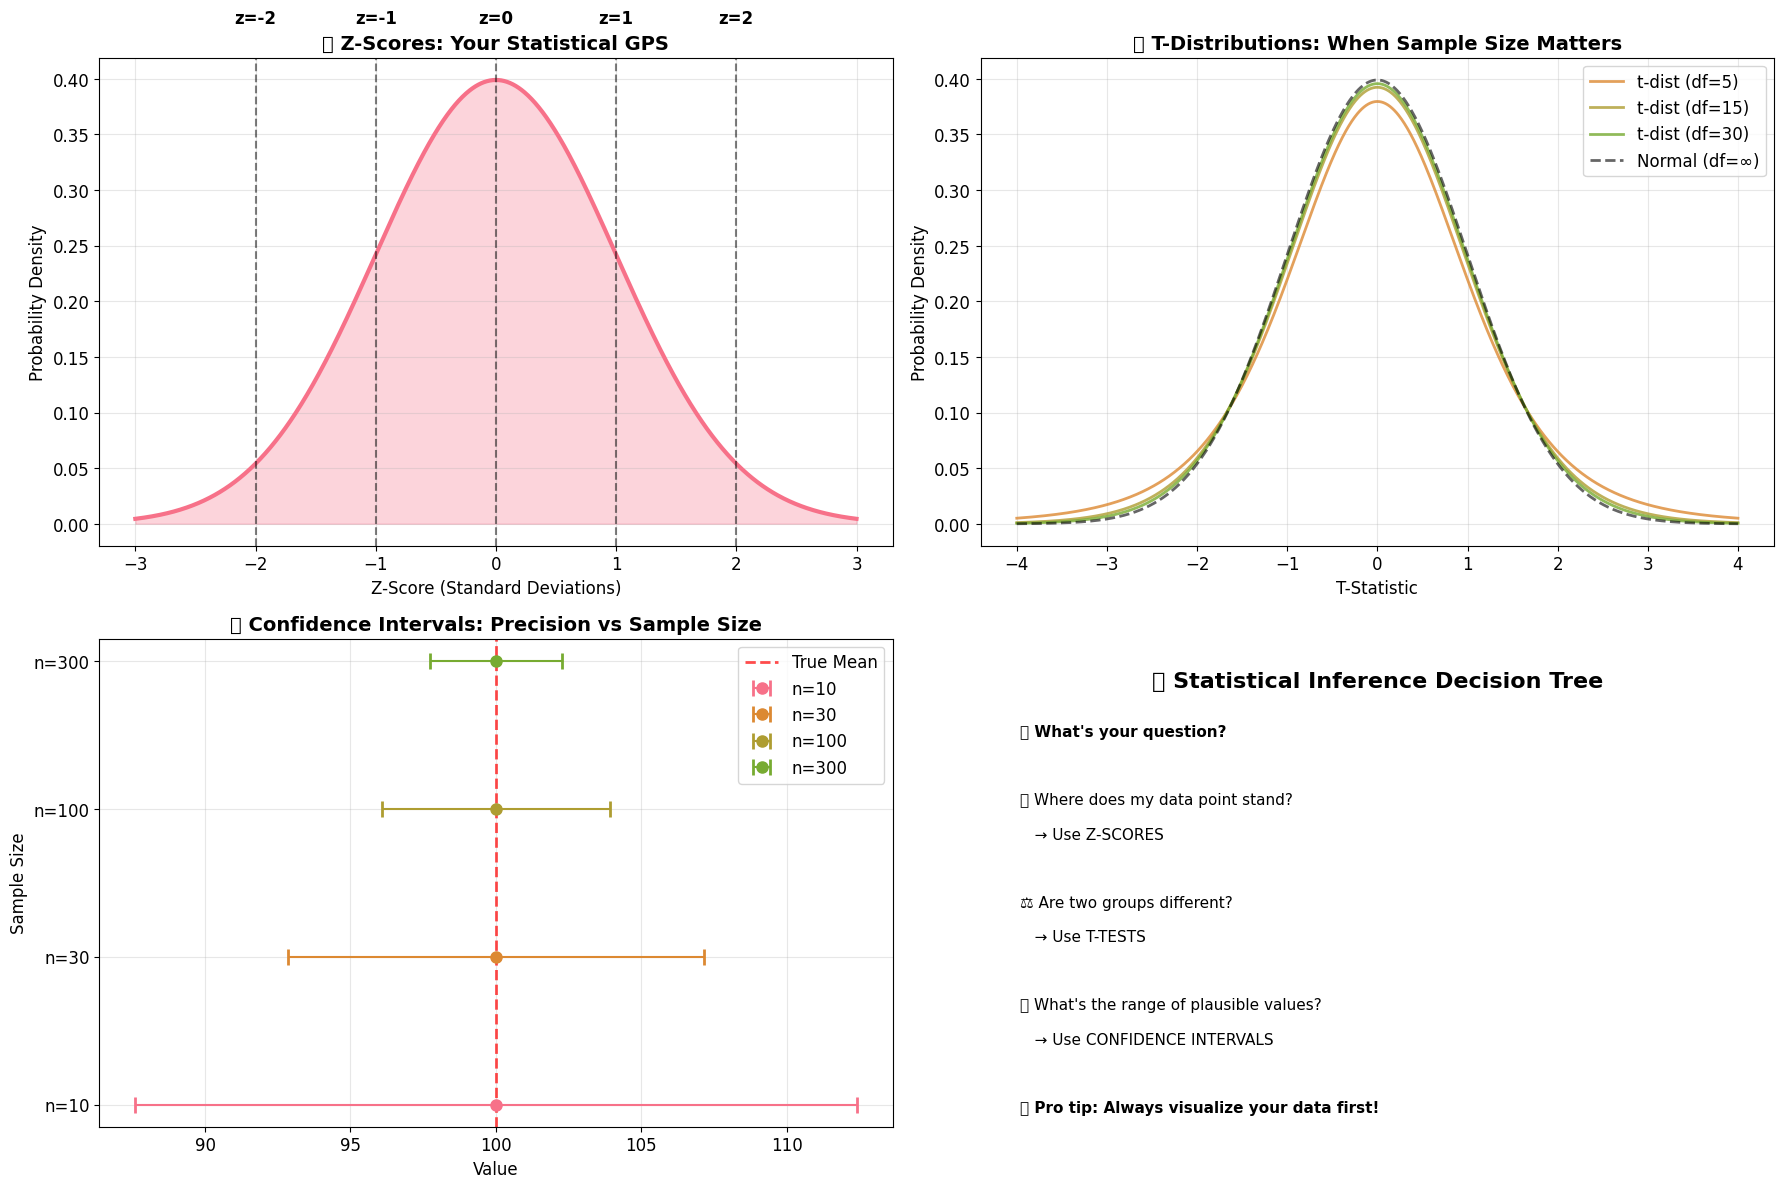

🎉 Congratulations! You now have a complete statistical inference toolkit!


In [23]:
# Create a comprehensive summary visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# Z-scores visualization
x = np.linspace(-3, 3, 1000)
y = stats.norm.pdf(x)
ax1.plot(x, y, linewidth=3, color=colors[0], label='Standard Normal')
ax1.fill_between(x, y, alpha=0.3, color=colors[0])

# Mark key z-scores
key_z = [-2, -1, 0, 1, 2]
for z in key_z:
    ax1.axvline(z, color='black', linestyle='--', alpha=0.5)
    ax1.text(z, 0.45, f'z={z}', ha='center', fontweight='bold')

ax1.set_title('🧭 Z-Scores: Your Statistical GPS', fontsize=14, fontweight='bold')
ax1.set_xlabel('Z-Score (Standard Deviations)')
ax1.set_ylabel('Probability Density')
ax1.grid(True, alpha=0.3)

# T-test visualization
x_t = np.linspace(-4, 4, 1000)
dfs = [5, 15, 30]
for i, df in enumerate(dfs):
    y_t = stats.t.pdf(x_t, df)
    ax2.plot(x_t, y_t, linewidth=2, color=colors[i+1], 
            label=f't-dist (df={df})', alpha=0.8)

# Add normal for comparison
y_norm = stats.norm.pdf(x_t)
ax2.plot(x_t, y_norm, '--', linewidth=2, color='black', 
        alpha=0.6, label='Normal (df=∞)')

ax2.set_title('🧪 T-Distributions: When Sample Size Matters', fontsize=14, fontweight='bold')
ax2.set_xlabel('T-Statistic')
ax2.set_ylabel('Probability Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Confidence intervals - effect of sample size
sample_sizes_demo = [10, 30, 100, 300]
true_mean_demo = 100
true_std_demo = 20

y_pos = 0
for n in sample_sizes_demo:
    se = true_std_demo / np.sqrt(n)
    margin = 1.96 * se  # 95% CI
    
    ax3.errorbar(true_mean_demo, y_pos, xerr=margin, fmt='o', 
                capsize=6, capthick=2, markersize=8, 
                color=colors[y_pos], label=f'n={n}')
    y_pos += 1

ax3.axvline(true_mean_demo, color='red', linestyle='--', linewidth=2, 
           alpha=0.7, label='True Mean')
ax3.set_yticks(range(len(sample_sizes_demo)))
ax3.set_yticklabels([f'n={n}' for n in sample_sizes_demo])
ax3.set_title('🎯 Confidence Intervals: Precision vs Sample Size', 
             fontsize=14, fontweight='bold')
ax3.set_xlabel('Value')
ax3.set_ylabel('Sample Size')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Summary decision tree
ax4.text(0.5, 0.9, '🎯 Statistical Inference Decision Tree', 
         transform=ax4.transAxes, ha='center', fontsize=16, fontweight='bold')

decision_tree = [
    "🤔 What's your question?",
    "",
    "📍 Where does my data point stand?",
    "   → Use Z-SCORES",
    "",
    "⚖️ Are two groups different?",
    "   → Use T-TESTS",
    "",
    "🎯 What's the range of plausible values?",
    "   → Use CONFIDENCE INTERVALS",
    "",
    "💡 Pro tip: Always visualize your data first!"
]

for i, line in enumerate(decision_tree):
    y_pos = 0.8 - i * 0.07
    ax4.text(0.05, y_pos, line, transform=ax4.transAxes, 
            fontsize=11, fontweight='bold' if line.startswith('🤔') or line.startswith('💡') else 'normal')

ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.show()

print("🎉 Congratulations! You now have a complete statistical inference toolkit!")

## Wrap-Up & Mastery Check
✅ You understand z-scores as your statistical GPS system  
✅ You can use t-tests to compare groups scientifically  
✅ You know how to build and interpret confidence intervals  
✅ You've seen these concepts come alive through beautiful visualizations  
✅ You can apply these tools to solve real business problems  

**Quick Reference Card:**
- 🧭 **Z-Scores**: (value - mean) / std → tells you how unusual a data point is
- 🧪 **T-Tests**: Compare group means, work with small samples too
- 🎯 **Confidence Intervals**: Range of plausible values for true parameter
- 📏 **Sample Size**: Bigger samples → narrower CIs → more precision
- 🎨 **Visualize**: Always plot your data and results!

**Real-World Applications You've Mastered:**
- Employee performance evaluation with z-scores
- Medical treatment comparison with t-tests
- Marketing campaign analysis with confidence intervals
- Quality control with statistical inference
- Survey research with uncertainty quantification

**Next Steps in Your Journey:**
These foundational concepts power everything else in statistics:
- **A/B Testing**: Uses t-tests and confidence intervals
- **Machine Learning**: Uses these concepts for model validation
- **Advanced Statistics**: ANOVA, regression, and more
- **Data Science**: Everything you've learned applies to real data science work

🚀 **You're now equipped with the core tools of statistical thinking!** Every data scientist, researcher, and analyst uses these concepts daily. The beautiful thing is that once you understand the logic and can create the visualizations, you can explain complex statistical concepts to anyone.

**Remember**: Statistics isn't about memorizing formulas - it's about understanding uncertainty, making comparisons, and quantifying confidence in your conclusions. You now have these superpowers! 🎯
